![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World! 

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [1]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


Finding

1. The highest frequency of crimes by hour? 
2. The largest frequency of night crimes (crimes committed between 10pm and 3:59am)? 
3. The number of crimes committed against victims of different age groups.

#Finding the frequencies of crimes by the hour of occurrence

In [2]:
#Extracting the hour

crimes['hour_occurrence'] = crimes['TIME OCC'].str[:2].astype(int)
crimes.head()
crimes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   DR_NO            185715 non-null  int64 
 1   Date Rptd        185715 non-null  object
 2   DATE OCC         185715 non-null  object
 3   TIME OCC         185715 non-null  object
 4   AREA NAME        185715 non-null  object
 5   Crm Cd Desc      185715 non-null  object
 6   Vict Age         185715 non-null  int64 
 7   Vict Sex         185704 non-null  object
 8   Vict Descent     185705 non-null  object
 9   Weapon Desc      73502 non-null   object
 10  Status Desc      185715 non-null  object
 11  LOCATION         185715 non-null  object
 12  hour_occurrence  185715 non-null  int64 
dtypes: int64(3), object(10)
memory usage: 18.4+ MB


<Axes: xlabel='hour_occurrence', ylabel='count'>

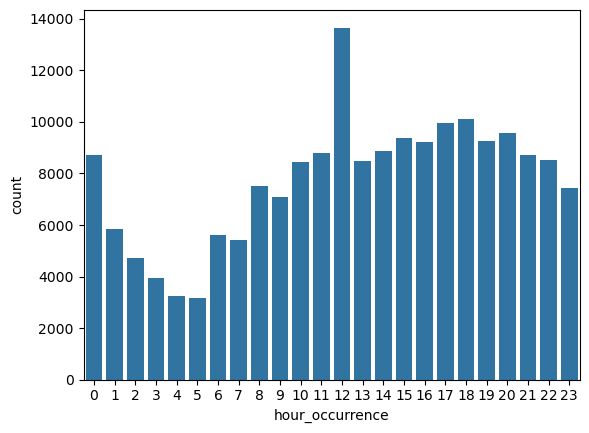

In [3]:
#Plotting the frequencies
sns.countplot(data=crimes, x='hour_occurrence')

In [4]:
peak_crime_hour = 12

Identifying the area with the most night crime

In [5]:
subset_night_hour = crimes[crimes['hour_occurrence'].isin([22, 23, 0, 1, 2, 3])]
subset_night_hour

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION,hour_occurrence
8,231207476,2023-02-27,2020-08-15,0001,77th Street,BURGLARY,72,M,B,NaN,Invest Cont,8800 HAAS AV,0
10,221711184,2022-06-15,2020-05-15,0155,Devonshire,THEFT OF IDENTITY,27,M,B,NaN,Invest Cont,8300 WHITE OAK AV,1
30,221314362,2022-07-11,2020-04-07,0001,Newton,THEFT OF IDENTITY,53,F,H,NaN,Invest Cont,1600 E OLYMPIC BL,0
33,231307252,2023-03-03,2020-07-05,2305,Newton,THEFT OF IDENTITY,22,F,B,NaN,Invest Cont,6600 S BROADWAY,23
36,221614254,2022-11-13,2020-01-01,0001,Foothill,THEFT OF IDENTITY,22,F,H,NaN,Invest Cont,10200 TELFAIR AV,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
185687,231306158,2023-02-11,2023-02-08,2200,Newton,BURGLARY FROM VEHICLE,38,M,H,NaN,Invest Cont,1700 E 16TH ST,22
185695,231212224,2023-05-17,2023-05-17,2300,77th Street,VIOLATION OF RESTRAINING ORDER,35,F,H,NaN,Invest Cont,8200 S MAIN ST,23
185700,231300825,2023-06-07,2023-06-07,2203,Newton,BATTERY - SIMPLE ASSAULT,45,F,B,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,2300 WALL ST,22
185701,230908346,2023-04-19,2023-04-18,2243,Van Nuys,THEFT OF IDENTITY,34,F,B,NaN,Invest Cont,4800 COLDWATER CANYON AV,22


In [6]:
#Counting crime by area
peak_night_crime_location = crimes.groupby('AREA NAME')['hour_occurrence'].count().sort_values(ascending=False).index[0]
print(f"Area with the largest frequency of night crimes (crimes committed between 10pm and 3:59am): {peak_night_crime_location}")

Area with the largest frequency of night crimes (crimes committed between 10pm and 3:59am): Central


Crimes by age group

In [7]:
#Creating bins and labels
#Adding a new column to the crimes DataFrame containing binned age bracket values
age_bins = [0, 17, 25, 34, 44, 54, 64, np.inf]
age_labels = [
    "0-17",
    "18-25",
    "26-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

crimes['age_bracket'] = pd.cut(crimes['Vict Age'], bins=age_bins, labels=age_labels) 
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION,hour_occurrence,age_bracket
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV,11,26-34
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST,16,55-64
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT,12,26-34
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV,6,35-44
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST,9,65+


In [8]:
#Counting crimes by victim age group
victim_ages = crimes['age_bracket'].value_counts(ascending=True)
victim_ages

age_bracket
0-17      4528
65+      14747
55-64    20169
18-25    28291
45-54    28353
35-44    42157
26-34    47470
Name: count, dtype: int64

In [9]:
#Adding time period column

# Define bins and labels
bins = [-1, 5, 11, 17, 23]
labels = ['Mid-night', 'Morning', 'Afternoon', 'Evening']

# Create the new column
crimes['Time_Period'] = pd.cut(crimes['hour_occurrence'], bins=bins, labels=labels)
crimes.tail()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION,hour_occurrence,age_bracket,Time_Period
185710,231510379,2023-05-29,2023-05-25,1100,N Hollywood,"BUNCO, GRAND THEFT",25,M,W,NaN,Invest Cont,5300 DENNY AV,11,18-25,Morning
185711,231604807,2023-01-27,2023-01-26,1800,Foothill,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",23,M,H,NaN,Invest Cont,12500 BRANFORD ST,18,18-25,Evening
185712,231606525,2023-03-22,2023-03-22,1000,Foothill,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",25,F,H,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",Invest Cont,12800 FILMORE ST,10,18-25,Morning
185713,231210064,2023-04-12,2023-04-12,1630,77th Street,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",29,M,B,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,6100 S VERMONT AV,16,26-34,Afternoon
185714,230906458,2023-03-05,2023-03-05,0900,Van Nuys,VANDALISM - MISDEAMEANOR ($399 OR UNDER),53,F,H,NaN,Invest Cont,14500 HARTLAND ST,9,45-54,Morning


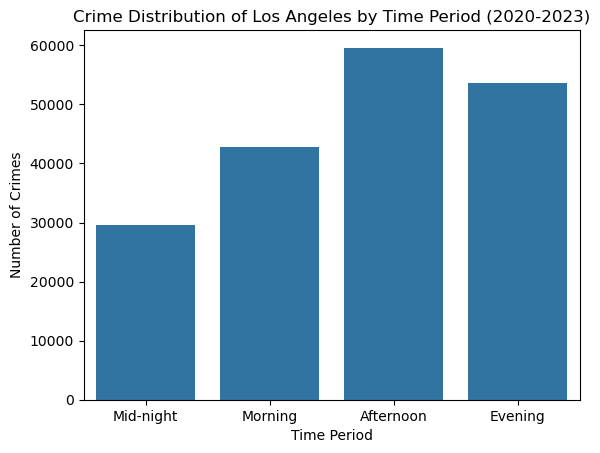

In [10]:
#Time period visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=crimes, x='Time_Period', order=['Mid-night','Morning','Afternoon','Evening'])

plt.title("Crime Distribution of Los Angeles by Time Period (2020-2023)")
plt.xlabel("Time Period")
plt.ylabel("Number of Crimes")

plt.show()

Insight:

Crime incidents are most frequent during the afternoon and evening periods, while the midnight to early morning hours show the lowest crime frequency, reflecting reduced public activity during those hours.

When Are Crimes Most Likely to Occur?

Question 

How does crime frequency change throughout the day?

Lowest crime hour: 5-hr, Number of crimes recorded: 3171
Peak crime hour: 12-hr, Number of crimes recorded: 13663


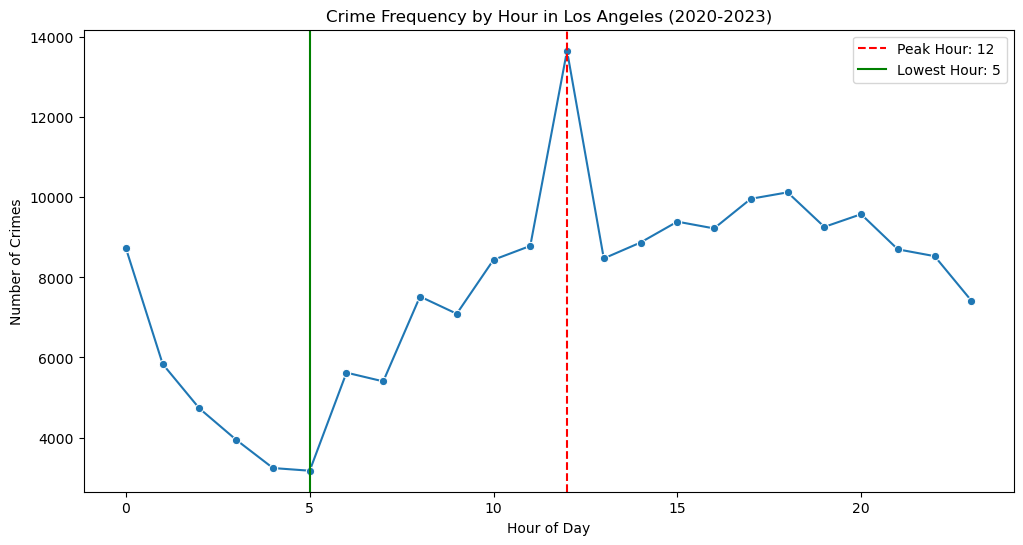

In [11]:
#count crimes for each hour.
crime_by_hour = crimes['hour_occurrence'].value_counts().sort_index()
lowest_crime_hour = crime_by_hour.idxmin()
peak_crime_hour = crime_by_hour.idxmax()
print(f"Lowest crime hour: {lowest_crime_hour}-hr, Number of crimes recorded: {crime_by_hour.min()}")
print(f"Peak crime hour: {peak_crime_hour}-hr, Number of crimes recorded: {crime_by_hour.max()}")

#Visualization for crimes for each hour

plt.figure(figsize=(12,6))
sns.lineplot(x=crime_by_hour.index, y=crime_by_hour.values, marker='o')
plt.axvline(peak_crime_hour, color='red', linestyle='--', label=f'Peak Hour: {peak_crime_hour}')
plt.axvline(lowest_crime_hour, color='green', linestyle='-', label=f'Lowest Hour: {lowest_crime_hour}')

plt.title("Crime Frequency by Hour in Los Angeles (2020-2023)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.legend()

plt.show()


Insight:

Crime occurrences in Los Angeles follow a clear daily cycle, with incidents increasing from the morning hours and peaking around midday. The lowest crime activity occurs in the early morning hours, particularly around 5 AM, when overall public activity is minimal.

Which Areas Are the Most Crime-Prone?

Question

Which Los Angeles divisions experience the highest crime rates?

In [12]:
#Group Crimes by Area
crime_by_area = crimes['AREA NAME'].value_counts()

#Get the Top 10 Crime Areas
top10_areas = crime_by_area.head(10)

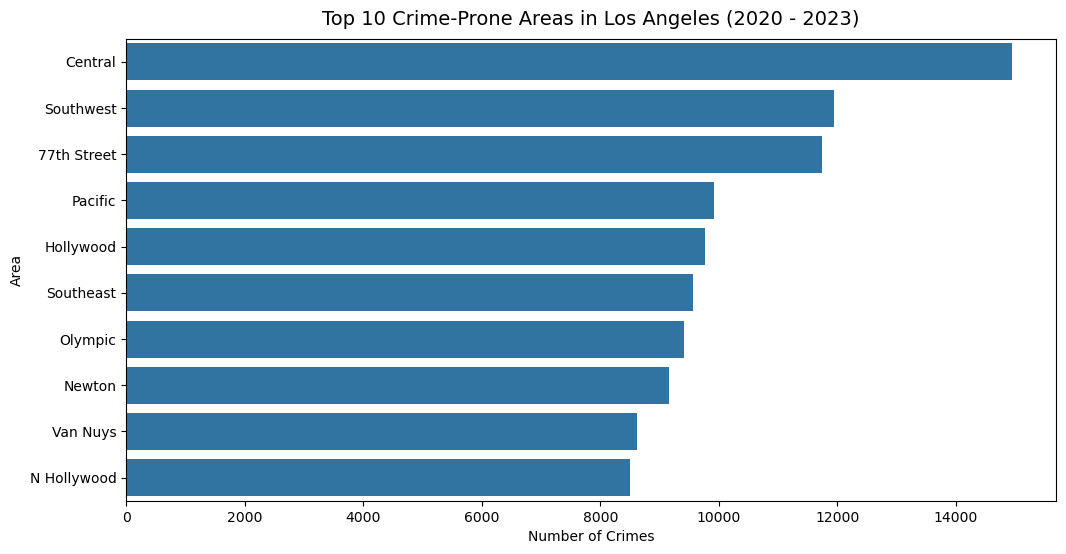

In [13]:
#Visualization of highest crime rates

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10_areas.values,
    y=top10_areas.index
)

plt.title("Top 10 Crime-Prone Areas in Los Angeles (2020 - 2023)", fontsize=14, pad=10)
plt.xlabel("Number of Crimes")
plt.ylabel("Area")

plt.show()

Insight:

Crime incidents are not evenly distributed across Los Angeles patrol divisions. The Central division reports the highest number of crimes, followed by the Southwest divisions and 77th Street. These areas likely experience higher crime rates due to increased population density, commercial activity, and urban congestion.

What Crimes Are Most Common in Los Angeles?

Question

What are the top crime categories reported?

Analysis

Use Crm Cd Desc.

Visualization

Horizontal bar chart of top 15 crimes

In [14]:
#Group Crimes by Area
crimes_reported = crimes['Crm Cd Desc'].value_counts()

#Get the Top 10 Crime Areas
top15_crimes = crimes_reported.head(15)

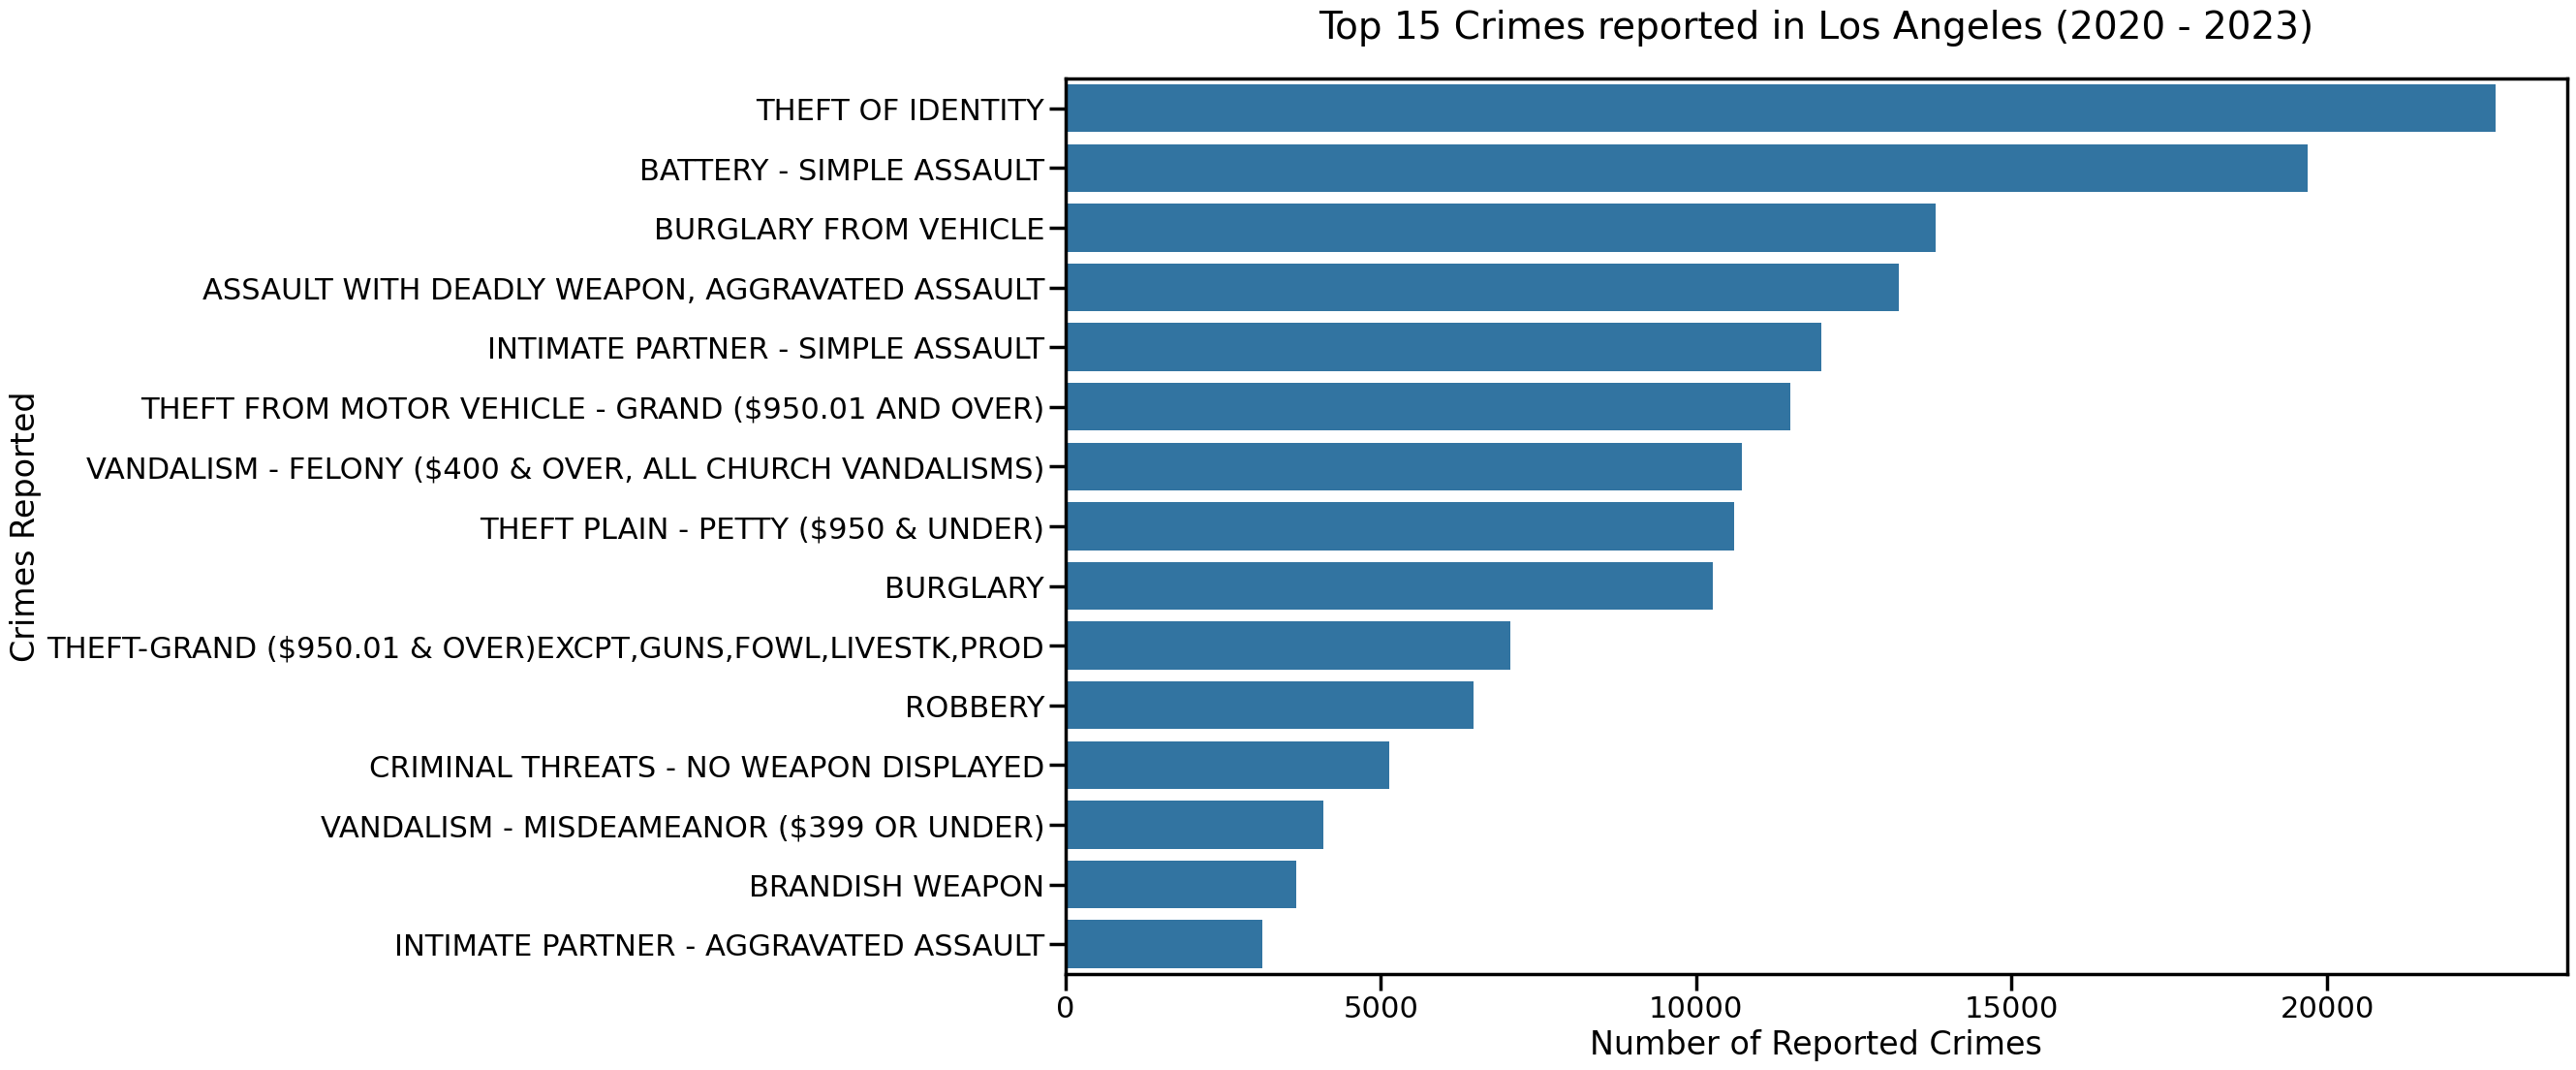

In [15]:
plt.figure(figsize=(20,12))
sns.set_context('poster')
sns.barplot(
    x=top15_crimes.values,
    y=top15_crimes.index
)

plt.title("Top 15 Crimes reported in Los Angeles (2020 - 2023)", fontsize=28, pad=30)
plt.xlabel("Number of Reported Crimes")
plt.ylabel("Crimes Reported")

plt.show()

Which Crimes Happen Most at Night?

Question

What types of crimes dominate nighttime hours (10 PM – 3:59 AM)?

Analysis

Filter by night hours.

Visualization

Stacked bar chart

In [16]:
#Filter by night
night_crimes = crimes[
    (crimes['hour_occurrence'] >= 22) |
    (crimes['hour_occurrence'] <= 3)
]

top_night_crimes = night_crimes['Crm Cd Desc'].value_counts().head(10)


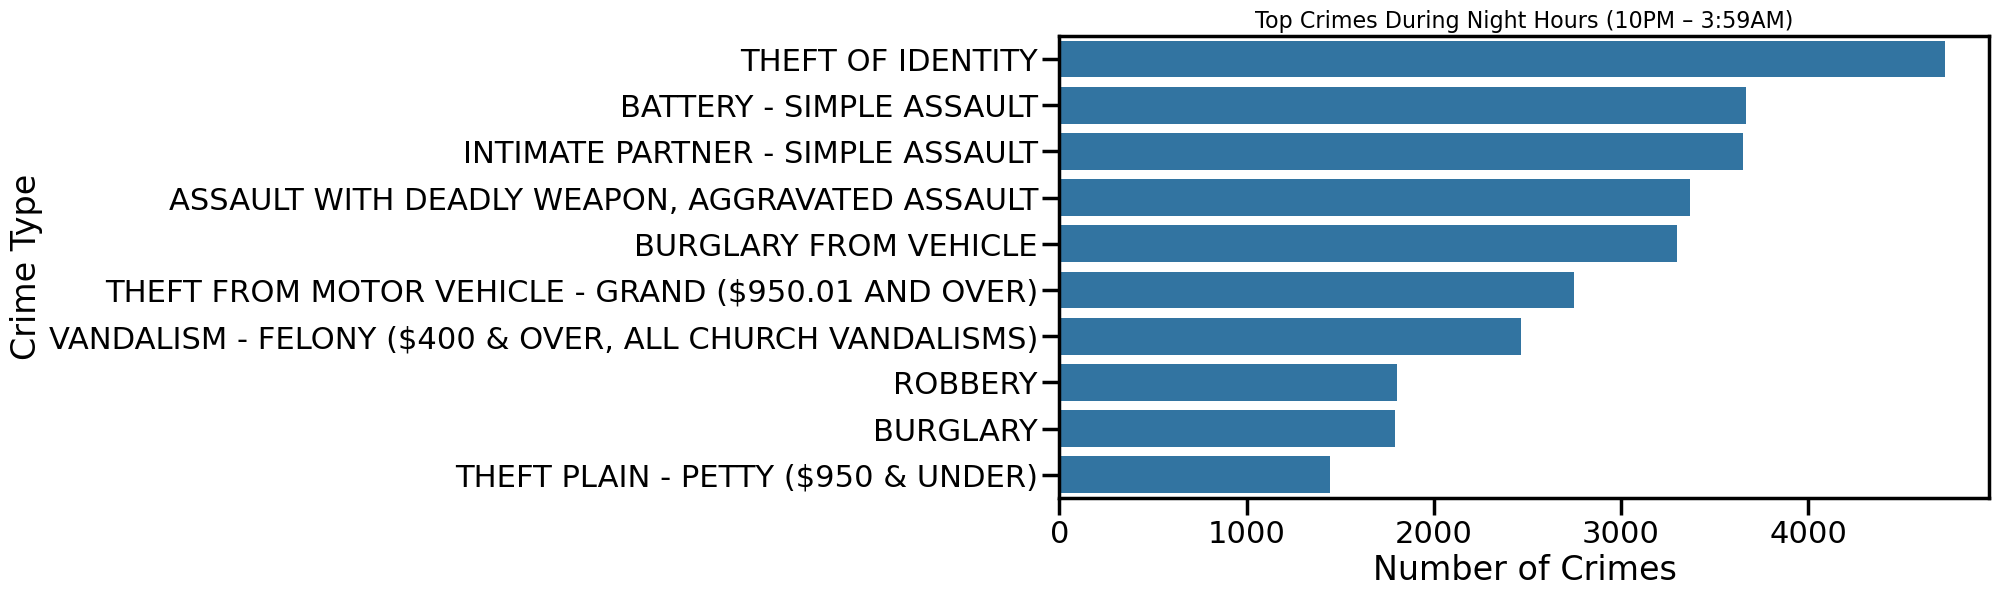

In [17]:
#Visualization

import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_night_crimes.values,
    y=top_night_crimes.index
)

plt.title("Top Crimes During Night Hours (10PM – 3:59AM)", fontsize=16)
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")

plt.show()

Which Age Groups Are Most Affected by Crime?
Question

How does crime victimization vary by age group?

You already created:

0–17

18–25

26–34

35–44

45–54

55–64

65+

Visualization

Bar chart of crime counts by age group

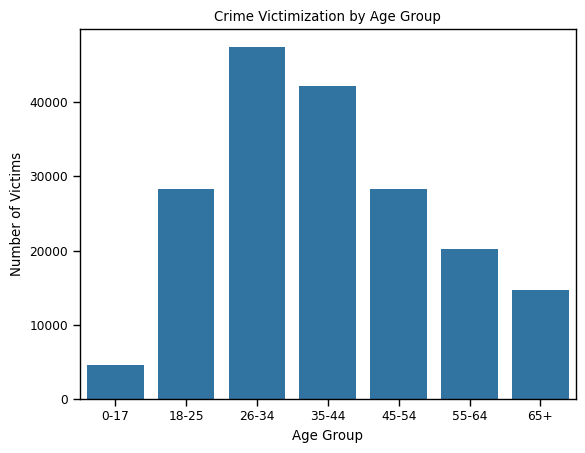

In [18]:

age_groups = ["0–17", "18–25", "26–34", "35–44", "45–54", "55–64", "65+"]
crime_counts = crimes['age_bracket'].value_counts()

sns.set_context('paper')
sns.barplot( x=crime_counts.index, y=crime_counts.values)

plt.title("Crime Victimization by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Victims")
plt.show()


How Does Crime Vary Across Days of the Week?

Question

Are crimes more common on weekdays or weekends?

Feature to create

Day_of_week from DATE OCC.

Visualization

Bar chart of crimes by weekday

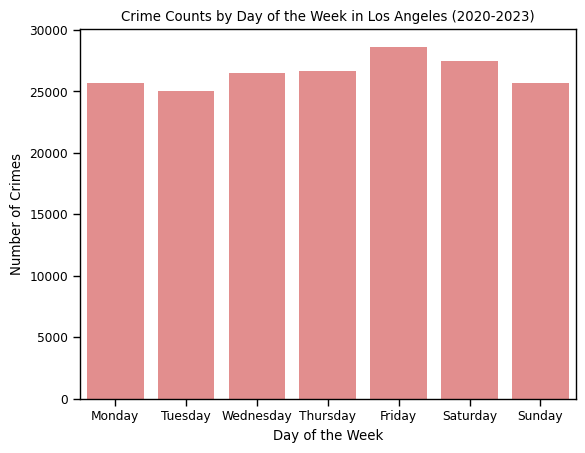

In [19]:

#DATE_OCC to datetime object
crimes['DATE OCC'] = pd.to_datetime(crimes['DATE OCC'])

# Extract the day of the week as a string (Monday, Tuesday, etc.)
crimes['Day_of_week'] = crimes['DATE OCC'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.countplot(data=crimes, x='Day_of_week', order=day_order, color='lightcoral')
plt.title("Crime Counts by Day of the Week in Los Angeles (2020-2023)")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Crimes")
plt.show()

What Time and Area Combination Has the Highest Crime Rate?
Question

Which area + hour combination produces the highest crime counts?

Visualization

Heatmap:

| Hour | Central | Hollywood | Southwest |

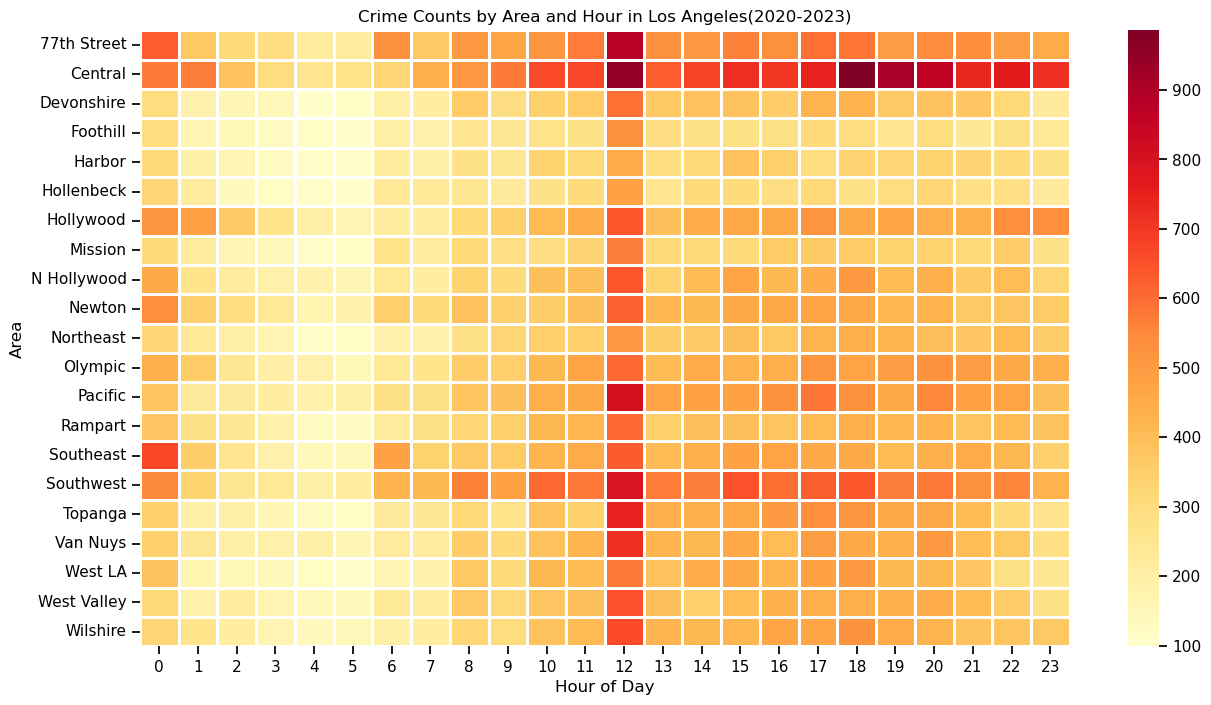

In [20]:
# Count crimes per area per hour
crime_matrix = crimes.pivot_table(index='AREA NAME', columns='hour_occurrence', values='DATE OCC', aggfunc='count', fill_value=0)

#Visualization
sns.set_context('notebook')
plt.figure(figsize=(15,8))
sns.heatmap(crime_matrix, cmap='YlOrRd', linewidths=1)
plt.title("Crime Counts by Area and Hour in Los Angeles(2020-2023)")
plt.xlabel("Hour of Day")
plt.ylabel("Area")
plt.show()

Crime Trend Over Time
Question

Is crime increasing or decreasing over time?

Visualization:

Line chart of crimes by month/year

C:\Users\ST FRANKLIN PC\AppData\Local\Temp\ipykernel_15056\539473217.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_crime_counts = crimes.groupby(['Year','Month']).size().reset_index(name='CrimeCount')


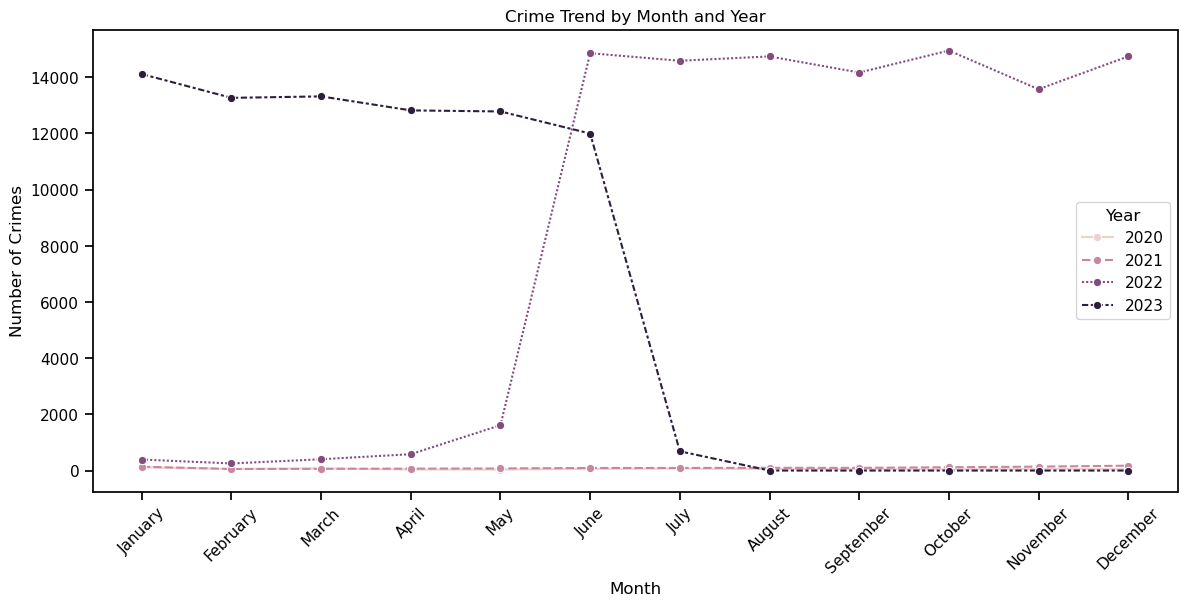

In [21]:
#Extract Month and Year into separate column

#Convert DATE OCC column data type into datetime
crimes['DATE OCC'] = pd.to_datetime(crimes['DATE OCC'])
#Create Year column
crimes['Year'] = crimes['DATE OCC'].dt.year
#Create Month column
crimes['Month'] = crimes['DATE OCC'].dt.month_name()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

crimes['Month'] = pd.Categorical(crimes['Month'], categories=month_order, ordered=True)

# Count crimes per Year and Month
monthly_crime_counts = crimes.groupby(['Year','Month']).size().reset_index(name='CrimeCount')

# Plot
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_crime_counts,
    x='Month',
    y='CrimeCount',
    hue='Year',
    style='Year',
    marker='o'
)

plt.title("Crime Trend by Month and Year")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)

plt.show()

